Đối với dictionary thông thường, ta không kiểm soát được kiểu dữ liệu cho mỗi key => dễ gây lỗi trong các hệ thống lớn => typed dictionary giúp khai báo kiểu dữ liệu cho từng key trong dictionary.

In [19]:
from typing import TypedDict #TypedDict là  một base class giúp định nghĩa các typed dictionary

In [13]:
class Movie(TypedDict): #khai báo type dictionary với fixed types cho từng key
    title: str
    year: int
#lưu ý: TypedDict chỉ lưu metadata cho type checker, thực chất python runtime vẫn coi TypeDict như 1 dict bình thường


In [25]:
#không thấy báo lỗi do vẫn coi TypedDict như dict bình thường
try:
    movie = Movie(title=2025)
    print(movie)
except Exception as e:
    print(f"Lỗi khi tạo movie: {e}")

{'title': 2025}


In [27]:
Movie.__annotations__ #in ra các kiểu dữ liệu đã khai báo cho từng key

{'title': str, 'year': int}

Union: khi khai báo kiểu dữ liệu cho một biến, ta cho phép biến đó có thể nhận nhiều kiểu dữ liệu khác nhau bằng cách sử dụng Union từ module typing.

In [29]:
from typing import Union

In [37]:
def square(x: Union[int,float]) -> float:
    """Return the square of a number (either int or float)."""
    return x * x

Optional: cho phép một biến có thể nhận kiểu dữ liệu đã định nghĩa hoặc None, sử dụng Optional từ module typing.

In [56]:
from typing import Optional
def greet(name: Optional[str]) -> str:
    """Return a greeting message. If name is None, use 'Guest'."""
    if name is None:
        name = "Guest"
    return f"Hello, {name}!"

In [57]:
a = greet("Quoc")
a

'Hello, Quoc!'

Any: cho phép một biến có thể nhận bất kỳ kiểu dữ liệu nào, sử dụng Any từ module typing.

In [59]:
from typing import Any
def print_value(x: Any) -> None:
    """Print the value of any type."""
    print(f"The value is: {x}")
print_value(42)

The value is: 42


state: lưu thông tin về trạng thái hiện tại của hệ thống (như kiểu metadata)

node: có thể là một llm, agent, nhận vào dữ liệu, xử lý và đưa ra output

toolnode: node chỉ bao gồm 1 tool để thực hiện 1 tác vụ cụ thể

edge: thể hiện node nào được thực hiện sau node nào

start: node bắt đầu workflow

end: node kết túc workflow

tool: các hàm mà agent sẽ gọi để thực hiện các tác vụ cụ thể

graph: tập hợp các node và connection giữa chúng (workflow)


In [63]:
pip install langgraph

In [65]:
#StateGraph: class graph trong langgraph
from langgraph.graph import StateGraph
from typing import TypedDict, Union


In [66]:
class AgentState(TypedDict):
    message: str

In [67]:
def greet_node(state: AgentState) -> AgentState: #state luôn là input và output của mỗi node trong graph, cần có dogstring để agent biết hàm này có tác dụng gì
    """Give a greeting message."""
    state['message'] = f"Hey, {state['message']}, how is your day going?"
    return state

In [71]:
graph = StateGraph(state_schema=AgentState) #khởi tạo graph với kiểu dữ liệu của state là AgentState
graph.add_node(node= "greeter", action = greet_node) #thêm node greet_node vào graph (lưu ý: node phải có input và output schema là state_schema của graph)
graph.set_entry_point(key = "greeter") #đặt node ban đầu của graph là "greeter"
graph.set_finish_point(key = "greeter") #đặt node kết thúc của graph là "greeter"
app = graph.compile() #compile grpah thành runnable

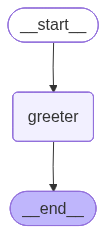

In [75]:
#display flow của graph
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))


In [77]:
#chạy graph
result = app.invoke({"message": "Quoc"})

In [78]:
result

{'message': 'Hey, Quoc, how is your day going?'}

Excercise 1: Personalized Compliment Agent

In [79]:
from typing import TypedDict
class ComplimentAgentState(TypedDict):
    message: str

In [80]:
def compliment(state: ComplimentAgentState) -> ComplimentAgentState:
    """Say compliment message to the user"""
    state["message"] = f"{state["message"]}, you're doing an amazing job learning LangGraph!"
    return state

In [82]:
from langgraph.graph import StateGraph
graph = StateGraph(state_schema= ComplimentAgentState)
graph.add_node(node = "complimenter", action = compliment)
graph.set_entry_point(key = "complimenter")
graph.set_finish_point(key = "complimenter")
app = graph.compile()

In [83]:
app.invoke({"message":"Quoc"})

{'message': "Quoc, you're doing an amazing job learning LangGraph!"}

Grap with multiple inputs

In [104]:
from typing import TypedDict, List
class AgentState(TypedDict):
    values: List[int]
    name: str
    result: str
    

In [111]:
def process_values(state: AgentState) -> AgentState:
    """Function handles multiple different inputs"""
    two_power_dict = list(map(lambda x: x*x,state["values"]))
    print(state)
    state["result"] = f"Hey {state["name"]}, your two_power_dict is: {two_power_dict}"
    print(state)
    return state
from langgraph.graph import StateGraph
graph = StateGraph(state_schema=AgentState)
graph.add_node(node = "process_values", action = process_values)
graph.set_entry_point(key = "process_values")
graph.set_finish_point(key = "process_values")
app = graph.compile()

In [113]:
app.invoke({"name":"Quoc", "values": [1,2,3,4]})

{'values': [1, 2, 3, 4], 'name': 'Quoc'}
{'values': [1, 2, 3, 4], 'name': 'Quoc', 'result': 'Hey Quoc, your two_power_dict is: [1, 4, 9, 16]'}


{'values': [1, 2, 3, 4],
 'name': 'Quoc',
 'result': 'Hey Quoc, your two_power_dict is: [1, 4, 9, 16]'}

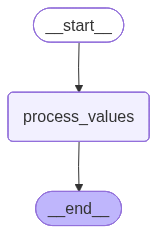

In [103]:
from IPython.display import display,Image
display(Image(app.get_graph().draw_mermaid_png()))

Excercise 2

In [186]:
from typing import TypedDict, List
class AgentState(TypedDict):
    name: str
    values: List[int]
    operator: str
    result: str

In [187]:
from functools import reduce
def perform_operator(state: AgentState) -> AgentState:
    """Perform specified operator in a list"""
    if state["operator"] == "+":
        processed_values = reduce(lambda x,y: x+y, state["values"])
        state["result"] = f"Hi {state["name"]}, your answer is {processed_values}"
    elif state["operator"] == "*":
        processed_values = reduce(lambda x,y: x*y, state["values"])
        state["result"] = f"Hi {state["name"]}, your answer is {processed_values}"
    else:
        print(state)
        print("invalid")
        state["result"] = f"Hi {state["name"]}, the operator is invalid"
    return state        

In [193]:
graph = StateGraph(state_schema = AgentState)
graph.add_node(node = "perform_operator", action = perform_operator)
graph.set_entry_point(key = "perform_operator")
graph.set_finish_point(key = "perform_operator")
agent = graph.compile()

In [ ]:
result = agent.invoke({"name": 'quoc', "values":[1,2,3,4,5], "operator": "**"})

{'name': 1, 'values': [1, 2, 3, 4, 5], 'operator': '**'}
invalid


Graph with sequential nodes

In [247]:
from typing import TypedDict
class AgentState(TypedDict):
    name: str
    age: int
    final: str
    

In [248]:
def first_node(state: AgentState) -> AgentState:
    """The first node of the graph"""
    state["final"] += f"Hi {state["name"]}. "
    return state

def second_node(state:AgentState) -> AgentState:
    """The second node of the graph"""
    state["final"] = state["final"] + f"Your age is {state["age"]}"
    return state
    

In [258]:
from langgraph.graph import StateGraph
graph = StateGraph(state_schema=AgentState)
graph.add_node(node = "first_node", action= first_node)
graph.add_node(node = "second_node", action = second_node)
graph.add_edge(start_key="first_node", end_key = "second_node")
graph.set_entry_point(key = "first_node")
graph.set_finish_point(key = "second_node")
app = graph.compile()

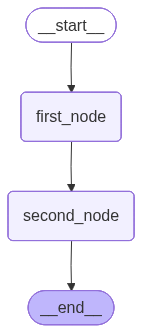

In [259]:
from IPython.display import display,Image
display(Image(app.get_graph().draw_mermaid_png()))

In [260]:
app.invoke({"name": "Quoc", "age": 21, "final": ""})

{'name': 'Quoc', 'age': 21, 'final': 'Hi Quoc. Your age is 21'}

Excercise 3:

In [261]:
from typing import TypedDict, List
class AgentState(TypedDict):
    name: str
    age: int
    skills: List
    final: str

In [271]:
def first_node(state: AgentState) -> AgentState:
    """Greeting name"""
    state["final"] = state.get("final","")
    state["final"] += f"{state["name"]}, welcome to the system! "
    return state
def second_node(state: AgentState) -> AgentState:
    """Formalize age"""
    state["final"] += f"You are {state["age"]} years old! "
    return state
def third_node(state: AgentState) -> AgentState:
    """List user's skills"""
    message = "You have skills in: "
    for i, skill in enumerate(state["skills"],0):
        if i == len(state["skills"])-1:
            message += f"and {skill}"
        else:
            message += f"{skill}, "
    state["final"] += message
    return state
    

In [272]:
from langgraph.graph import StateGraph
graph = StateGraph(state_schema= AgentState)
graph.add_node(node = "first_node",action = first_node)
graph.add_node(node = "second_node", action = second_node)
graph.add_node(node = "third_node", action = third_node)
graph.add_edge(start_key = "first_node", end_key="second_node")
graph.add_edge(start_key="second_node", end_key="third_node")
graph.set_entry_point(key ="first_node")
graph.set_finish_point(key = "third_node")
app = graph.compile()

In [274]:
app.invoke({"name": "Quoc", "age": 15, "skills": ["Python", "Java", "SQL", "Docker"]})

{'name': 'Quoc',
 'age': 15,
 'skills': ['Python', 'Java', 'SQL', 'Docker'],
 'final': 'Quoc, welcome to the system! You are 15 years old! You have skills in: Python, Java, SQL, and Docker'}

Graph 4: Conditional Graph

In [275]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END

In [276]:
class AgentState(TypedDict):
    number1: int
    number2: int
    operation: str
    finalNumber: int

In [277]:
def adder(state: AgentState) -> AgentState:
    """Add the two numbers"""
    state["finalNumber"] = state["number1"] + state["number2"]
    return state

def subtract(state: AgentState) -> AgentState:
    """Subtract the two numbers"""
    state["finalNumber"]= state["number1"] - state["number2"]
    return state

In [292]:
#router decides which branch will work
def router(state: AgentState) -> AgentState:
    """Select the node to the graph"""
    if state["operation"] == "+":
        return "addition_operation"
    elif state["operation"] == "-":
        return "subtract_operation"

In [ ]:
from langgraph.graph import StateGraph
graph = StateGraph(state_schema= AgentState)
graph.add_node(node = "adder", action = adder)
graph.add_node(node = "subtract", action = subtract)
graph.add_node(node="router", action = lambda state: state) #router giữ nguyên output
graph.add_edge(START,"router")
graph.add_conditional_edges(source = "router",path = router, path_map = {"addition_operation": "adder", "subtract_operation": "subtract"}) #source sẽ được thực hiện trước path
graph.add_edge("adder", END)
graph.add_edge("subtract", END)
app = graph.compile()

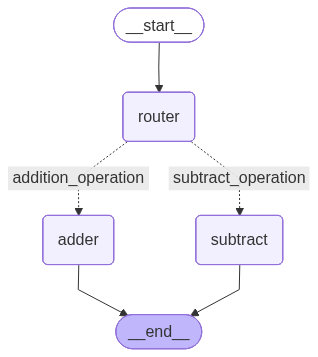

In [294]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [295]:
app.invoke({"number1": 10, "number2": 5, "operation": "-"})

{'number1': 10, 'number2': 5, 'operation': '-', 'finalNumber': 5}

Excercise 4:

In [11]:
from typing import TypedDict, Union
class AgentState(TypedDict):
    number1: int
    number2: int
    number3: int
    number4: int
    operation1: str
    operation2: str
    finalanswer: int
    finalanswer2: int
    

In [12]:
def adder1(state: AgentState) -> AgentState:
    """Add two numbers"""
    state["finalanswer"] = state["number1"] + state["number2"]
    return state
def subtract1(state: AgentState) -> AgentState:
    """Subtract two numbers"""
    state["finalanswer"] = state["number1"] - state["number2"]
    return state

def adder2(state: AgentState) -> AgentState:
    """Add two numbers"""
    state["finalanswer2"] = state["number3"] + state["number4"]
    return state
def subtract2(state: AgentState) -> AgentState:
    """Subtract two numbers"""
    state["finalanswer2"] = state["number3"] - state["number4"]
    return state

def router1(state: AgentState) -> AgentState:
    """Select the first operation"""
    if state["operation1"] == "+":
        return "addition_operation1"
    elif state["operation1"] == "-":
        return "subtract_operation1"

def router2(state: AgentState) -> AgentState:
    """Select the second operation"""
    if state["operation2"] == "+":
        return "addition_operation2"
    elif state["operation2"] == "-":
        return "subtract_operation2"
    

In [13]:
from langgraph.graph import StateGraph, START, END
graph = StateGraph(state_schema= AgentState)
graph.add_node(node = "adder1", action = adder1)
graph.add_node(node = "subtract1", action = subtract1)
graph.add_node(node = "adder2", action = adder2)
graph.add_node(node = "subtract2", action = subtract2)
graph.add_node(node="router1", action = lambda state: state) #router1 giữ nguyên output
graph.add_node(node="router2", action = lambda state: state) #router2 giữ
graph.add_edge(START, "router1")
graph.add_edge("adder2", END)
graph.add_edge("subtract2", END)
graph.add_conditional_edges(source = "router1", path = router1, path_map = {"addition_operation1": "adder1", "subtract_operation1": "subtract1"})
graph.add_edge("adder1", "router2")
graph.add_edge("subtract1", "router2")
graph.add_conditional_edges(source = "router2", path = router2, path_map = {"addition_operation2": "adder2", "subtract_operation2": "subtract2"})
app = graph.compile()

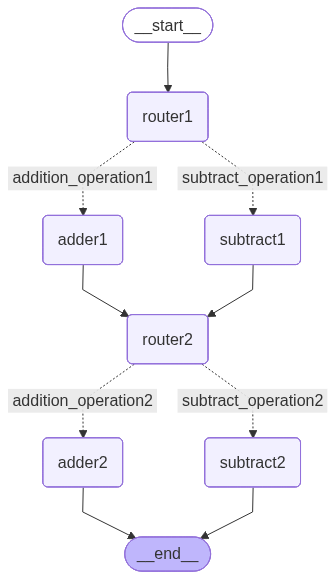

In [14]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [15]:
app.invoke({"number1": 20, "number2": 5, "number3": 10, "number4": 2, "operation1": "+", "operation2": "-"})

{'number1': 20,
 'number2': 5,
 'number3': 10,
 'number4': 2,
 'operation1': '+',
 'operation2': '-',
 'finalanswer': 25,
 'finalanswer2': 8}

Graph 5: Looping Graph

In [2]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
import random

In [3]:
class AgentState(TypedDict):
    name: str
    numbers: List[int]
    counter: int

In [29]:
def greeting(state: AgentState) -> AgentState:
    """Greet the user"""
    state["counter"] = 0
    state["name"] = f"Hello {state['name']}! Let's start processing your numbers."
    state["numbers"] =[]
    return state
def random_process(state:AgentState) -> AgentState:
    """Randomly process numbers"""
    random_number = random.randint(0,100)
    state["numbers"].extend([random_number])
    state["counter"] += 1
    return state

def should_continue(state: AgentState) -> AgentState:
    """Decide if we should continue to iterate the random process"""
    if state["counter"] <5:
        return "loop"
    else:
        return "end"

In [30]:
graph = StateGraph(state_schema=AgentState)
graph.add_node(node = "greeting", action = greeting)
graph.add_node(node = "random_process",action = random_process)
graph.add_conditional_edges(source = "random_process", path = should_continue, path_map={"loop": "random_process", "end": END})
graph.add_edge(START,"greeting")
graph.add_edge("greeting","random_process")
app = graph.compile()


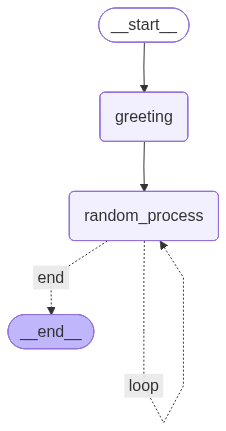

In [31]:
from IPython.display import display,Image
display(Image(app.get_graph().draw_mermaid_png()))

In [33]:
app.invoke({"name":"Quoc", "counter": -4})

{'name': "Hello Quoc! Let's start processing your numbers.",
 'numbers': [61, 26, 4, 2, 11],
 'counter': 5}

Graph excercise 5:

In [34]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END

In [38]:
class AgentState(TypedDict):
    player_name: str
    guesses: List[int]
    lower_bound: int
    upper_bound: int
    attempts: int
    target_num: int
    

In [115]:
import random
def set_up(state: AgentState) -> AgentState:
    """Set up the variables for the pipeline"""
    state["guesses"] = []
    state["attempts"] = 0
    return state

def guess(state: AgentState) -> AgentState:
    """Guess the target_num"""
    random_number = random.randint(state["lower_bound"], state["upper_bound"])
    state["guesses"].append(random_number)
    print(f"Guess number: {random_number}")
    state["attempts"] +=1
    return state

def hint(state:AgentState) -> AgentState:
    """Get the hint if guess is incorrect"""
    if state["target_num"] > state["guesses"][-1]:
        print("Hint say: Higher")
        state["lower_bound"] = state["guesses"][-1] +1
    elif state["target_num"] < state["guesses"][-1]:
        print("Hint say: Lower")
        state["upper_bound"] = state["guesses"][-1] -1
    else:
        return state
    print(f"Lower bound: {state['lower_bound']}, Upper bound: {state['upper_bound']}")
    return state

def should_continue(state: AgentState)-> AgentState:
    if state["target_num"] == state["guesses"][-1]:
        print("Congratulation, we got the right answer")
        return "end_loop"
    elif state["attempts"] ==7:
        print("Cannot find the right answer")
        return "end_loop"
    else:
        return "loop"
            
    

In [116]:
graph = StateGraph(state_schema=AgentState)
graph.add_node(node = "set_up", action = set_up)
graph.add_node(node = "guess", action = guess)
graph.add_node(node = "hint", action = hint)
graph.add_conditional_edges(source = "hint", path = should_continue, path_map = {"end_loop": END, "loop":"guess"})
graph.add_edge(START, "set_up")
graph.add_edge("guess", "hint")
graph.add_edge("set_up", "guess")
app = graph.compile()

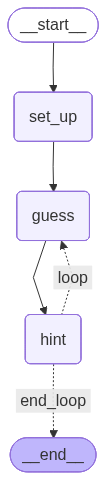

In [108]:
from IPython.display import display,Image
display(Image(app.get_graph().draw_mermaid_png()))

In [117]:
app.invoke({"name": "Quoc", "lower_bound":1, "upper_bound":100, "target_num":7})

Guess number: 42
Hint say: Lower
Lower bound: 1, Upper bound: 41
Guess number: 4
Hint say: Higher
Lower bound: 5, Upper bound: 41
Guess number: 9
Hint say: Lower
Lower bound: 5, Upper bound: 8
Guess number: 8
Hint say: Lower
Lower bound: 5, Upper bound: 7
Guess number: 7
Congratulation, we got the right answer


{'guesses': [42, 4, 9, 8, 7],
 'lower_bound': 5,
 'upper_bound': 7,
 'attempts': 5,
 'target_num': 7}

Graph: Simple LLM Chatbot

In [118]:
from dotenv import load_dotenv
load_dotenv()

True

In [121]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph
from typing import TypedDict, List

In [127]:
llm = ChatGoogleGenerativeAI(model= "gemini-1.5-flash", temperature= 0.5)

In [132]:
llm = ChatGoogleGenerativeAI(model = "gemini-2.5-flash",temperature=0.5)

In [154]:
message1 = HumanMessage(content = "Who are you?")
message2 = HumanMessage(content = "Who is Ronaldo?")

In [147]:
class AgentState(TypedDict):
    messages: List[HumanMessage]

In [162]:
def process(state: AgentState) -> AgentState:
    """Generate the response through an LLM"""
    response = llm.invoke(state["messages"])
    print(f" AI Response: {response.content}")
    return state

In [163]:
graph = StateGraph(state_schema= AgentState)
graph.add_node(node = "process", action = process)
graph.set_entry_point(key = "process")
graph.set_finish_point(key = "process")
app = graph.compile()

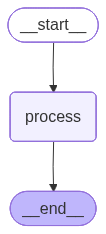

In [164]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [165]:
user_input = "Who are you?"
app.invoke({"messages": [HumanMessage(user_input)]})

 AI Response: I am a large language model, trained by Google.

I don't have a name, personal identity, feelings, consciousness, or a physical body. My purpose is to assist users by providing information and completing tasks based on the data I was trained on.


{'messages': [HumanMessage(content='Who are you?', additional_kwargs={}, response_metadata={})]}

In [168]:
user_input = input("Enter: ")
while user_input != "exit":
    app.invoke({"messages": [HumanMessage(user_input)]})

 AI Response: Hi there! How can I help you today?
 AI Response: Hi there! How can I help you today?
 AI Response: Hello! How can I assist you today?
 AI Response: Hi there! How can I help you today?
 AI Response: Hi there! How can I help you today?
 AI Response: Hi there! How can I help you today?


KeyboardInterrupt: 

Cấu trúc fan in fan out

In [2]:
from typing import TypedDict, List, Annotated, Sequence
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage, SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [32]:
load_dotenv()

class AgentState(TypedDict):
    messages: Annotated[List[int], add_messages]

In [131]:
def add_message_a(state: AgentState) -> AgentState:
    """Add message a"""
    return {"messages": ["This is message A."]}

def add_message_b(state: AgentState) -> AgentState:
    """Add message b"""
    return {"messages": ["This is message B."]}

def add_message_c(state: AgentState) -> AgentState:
    """Add message c"""
    return {"messages": ["This is message C."]}

def add_message_d(state: AgentState) -> AgentState:
    """Add message d"""
    return {"messages": ["This is message D."]}

def add_message_e(state: AgentState) -> AgentState:
    """Add message e"""
    return {"messages": ["This is message E."]}

In [ ]:
graph = StateGraph(state_schema= AgentState)
#cơ chế super step: tại step 1, node a được thực hiện => step 2, tất cả các node có a là input đều được thực hiện (ví dụ là b,d,c) => step 3 (tất cả các node có b,c,d là input đều được thực hiện (ví dụ b,e))
#trong langraph các thuộc tính (không phải reducer) của state sẽ chỉ thay đổi (overwrite giá trị cũ) nếu ta có đưa vào return. => nếu ta không bao gồm attribute trong return, attribute đó trong state vẫn sẽ giữ nguyên
# => không nên sửa trực tiếp state trong hàm
graph.add_node(node = "a", action = add_message_a)
graph.add_node(node = "b", action = add_message_b)
graph.add_node(node = "c", action = add_message_c)
graph.add_node(node = "d", action = add_message_d)
graph.add_node(node = "e", action = add_message_e)
graph.add_edge("a", "c")
graph.add_edge(START, "a")
graph.add_edge("a", "b")
graph.add_edge("a", "d")
graph.add_edge("b", "e")
graph.add_edge("c", "e")
graph.add_edge("d", "e")
graph.add_edge("e", END)
app = graph.compile()

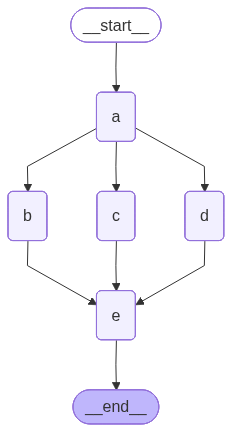

In [116]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [133]:
#cơ chế hoạt động của add_message: 
#nếu tin nhắn mới không có id hoặc id khác với các tin nhắn trước đó thì tin nhắn mới sẽ được thêm vào danh sách tin nhắn
#nếu tính nhắn mới có id trùng với tin nhắn trước đó thì tin nhắn mới sẽ không được thêm vào danh sách tin nhắn
#lưu ý nguyên tắc khi sử dụng add_messages: không thay đổi trực tiếp state["messages"], mà phải return một dictionary với update mà ta muốn thực hiện"
message = []
app.invoke({"messages": []})

{'messages': [HumanMessage(content='This is message A.', additional_kwargs={}, response_metadata={}, id='c2849eca-88e7-40c2-be34-bdae8d42a41d'),
  HumanMessage(content='This is message B.', additional_kwargs={}, response_metadata={}, id='65301706-6cd2-4d3d-afcf-4f313ef1fec3'),
  HumanMessage(content='This is message C.', additional_kwargs={}, response_metadata={}, id='a0649894-f8d9-401f-8329-ffa579eac081'),
  HumanMessage(content='This is message D.', additional_kwargs={}, response_metadata={}, id='9de3b2d4-a18c-422e-a26f-77d982f0ad91'),
  HumanMessage(content='This is message E.', additional_kwargs={}, response_metadata={}, id='c61c50c2-7088-42ac-80b5-045568ad44ba')]}

Memory saver: cơ chế lưu trữ state của agent trong RAM

In [3]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [4]:
load_dotenv()
llm = ChatGoogleGenerativeAI(model = "gemini-2.5-flash", temperature = 0.3)

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [6]:
def setup(state: AgentState) -> AgentState:
    query = input("Hello! I am the AI Assistant. How can I help you today?\n")
    ai_message = AIMessage(content = "Hello! I am the AI Assistant. How can I help you today?")
    ai_message.pretty_print()
    return {"messages": [ai_message, HumanMessage(content = query)]}

def answer_query(state: AgentState) -> AgentState:
    system_content = """
    You are the AI Assistant that helps answer user's querys
    """
    system_message = SystemMessage(content = system_content)
    all_messages = [system_message] + list(state["messages"])
    respond = llm.invoke(all_messages)
    respond.pretty_print()
    return {"messages": [respond]}

def get_human_response(state: AgentState) -> AgentState:
    query = input("")
    return {"messages": [HumanMessage(content = query)]}


def should_continue(state: AgentState) -> str:
    last_message = state["messages"][-1]
    if isinstance(last_message, HumanMessage) and last_message.content.lower() in ["exit", "quit", "bye"]:
        print("Ending the conversation. Goodbye!")
        return "end_conversation"
    else:
        return "continue_conversation"
    
graph = StateGraph(state_schema= AgentState)
graph.add_node("setup", action = setup)
graph.add_node("answer_query", action = answer_query)
graph.add_node("get_human_response", action = get_human_response)
graph.add_edge(START, "setup")
graph.add_edge("setup", "answer_query")
graph.add_edge("answer_query", "get_human_response")
graph.add_conditional_edges(source = "get_human_response", path = should_continue, path_map={"end_conversation": END, "continue_conversation": "answer_query"})
app = graph.compile(checkpointer= memory)

In [ ]:
app.invoke({"messages": []}, config= {"configurable": {"thread_id": "first_conversation"}} )